# Predictive spiking controller

First closed-loop version of the predictive spiking controller, with no noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm

In [2]:
A = np.array([
    [0.0, 1],            # position rate = 1 * velocity
    [-0.1, -0.1]         # velocity rate = stiffness + damping
])

B = np.array([           # spike-to-force map  
    [0.0, 0.0],
    [2.0, -2.0]          # N1 spikes velocity with +2 and N2 spikes velocity with -2
])


C  = np.diag([20.0, 1.0])      # cost weights: position penalised 20x more than velocity

T = 100                  # total simulated time (s)
dt = 0.01                # output sampling step
t_eval = np.arange(0, T, dt)
f  = 0.1                 # predictive horizon (s)
mu = 0.1                 # spike cost
z_schedule = [(5.0, 5.0), (15.0, 10.0), (30.0, 15.0)]     # (time, target) steps

x0 = [0.0, 0.0]  

Af    = expm(A * f) 
G     = B.T @ Af.T @ C  

thresholds = np.zeros(B.shape[1])

# Spike threshold per neuron
for i in range(B.shape[1]):
    thresholds[i] = 0.5 * B[:, i] @ Af.T @ C @ Af @ B[:, i] + mu

# low-pass filter the step schedule into a smooth reference z(t)
def get_target(t, z_prev, dt):
    z_base = 0.0
    for t_point, val in z_schedule:
        if t >= t_point:
            z_base = val
    return z_prev + dt * 0.5 * (z_base - z_prev)

In [3]:
nT = len(t_eval)
x  = np.zeros((nT, 2))
z  = np.zeros(nT) 
x[0] = x0

for i in range(nT - 1):
    z[i+1] = get_target(t_eval[i], z[i], dt)
    target_vec = np.array([z[i], 0.0])           # desired [position, velocity]
    
    V = G @ (target_vec - Af @ x[i])             # per-neuron voltage
    
    difference = V - thresholds
    s = np.zeros(2)
    if difference.max() > 0:
        s[np.argmax(difference)] = 1.0           # winner-take-all: one spike for the best neuron

    x[i+1] = x[i] + dt * (A @ x[i]) + B @ s      # plant update with the chosen spike



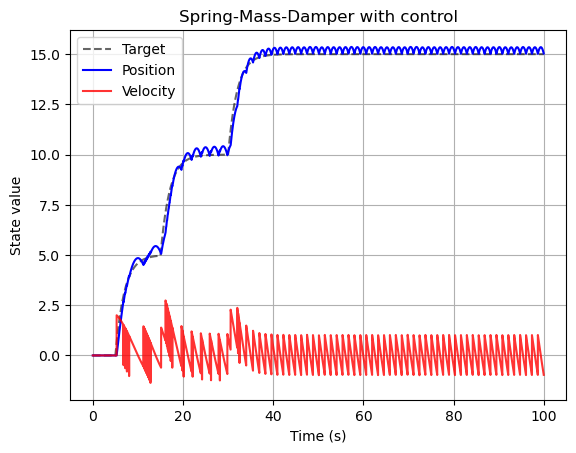

In [4]:
plt.plot(t_eval, z, 'k--', alpha=0.6, label="Target")
plt.plot(t_eval, x[:, 0], color='blue',  label="Position")
plt.plot(t_eval, x[:, 1], color='red', alpha=0.8, label="Velocity")
plt.xlabel("Time (s)")
plt.ylabel("State value")
plt.title("Spring-Mass-Damper with control")
plt.legend()
plt.grid()
plt.show()